In [22]:
# Import libraries

import glob
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [ ]:
# Load all available months of Sold data so we have room to
# experiment with different training window lengths (X)
files = sorted(glob.glob("data/CRMLSSold*.csv"))
print(f"Found {len(files)} monthly files:", files[0], "...", files[-1])

df = pd.concat(
    [pd.read_csv(file, low_memory=False) for file in files],
    ignore_index=True
)

print(df.shape)

Found 29 monthly files: data/CRMLSSold202401.csv ... data/CRMLSSold202605.csv
(624754, 84)


In [6]:
# Keep only Residential Single Family homes
df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(df.shape)

(314368, 84)


In [7]:
# Features we will use for preprocessing
features = [
    "CloseDate",
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "City",
    "CountyOrParish",
    "YearBuilt",
    "DaysOnMarket",
]

prep_df = df[features].copy()
prep_df.head()

,CloseDate,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,City,CountyOrParish,YearBuilt,DaysOnMarket
5,2024-01-05,815000.0,1974.0,4.0,4.0,NaN,National City,San Diego,2023.0,33
9,2024-01-05,810000.0,1974.0,4.0,4.0,NaN,National City,San Diego,2023.0,228
28,2024-01-30,858000.0,1995.0,0.0,3.0,13504.0,Palm Springs,Riverside,1959.0,0
29,2024-01-29,1890500.0,3194.0,5.0,3.0,17873.0,Tarzana,Los Angeles,1955.0,0
30,2024-01-02,2100000.0,3736.0,4.0,4.0,11219.0,San Luis Obispo,San Luis Obispo,2019.0,0


In [8]:
# Convert date column
prep_df["CloseDate"] = pd.to_datetime(prep_df["CloseDate"], errors="coerce")

# Create month column for train/test split
prep_df["CloseMonth"] = prep_df["CloseDate"].dt.to_period("M").astype(str)

prep_df[["CloseDate", "CloseMonth"]].head()

,CloseDate,CloseMonth
5,2024-01-05,2024-01
9,2024-01-05,2024-01
28,2024-01-30,2024-01
29,2024-01-29,2024-01
30,2024-01-02,2024-01


In [9]:
# Check missing values
prep_df.isna().sum()

CloseDate                   0
ClosePrice                  2
LivingArea                171
BedroomsTotal               0
BathroomsTotalInteger      50
LotSizeSquareFeet        5450
City                      248
CountyOrParish              0
YearBuilt                 227
DaysOnMarket                0
CloseMonth                  0
dtype: int64

In [10]:
# Drop rows missing target or date
prep_df = prep_df.dropna(subset=["ClosePrice", "CloseDate"])

# Impute numerical missing values using median
num_cols = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "DaysOnMarket"
]

cat_cols = ["City", "CountyOrParish"]

flag_cols = []
for col in num_cols + cat_cols:
    if prep_df[col].isna().any():
        flag_name = f"{col}_was_missing"
        prep_df[flag_name] = prep_df[col].isna().astype(int)
        flag_cols.append(flag_name)

for col in num_cols:
    prep_df[col] = prep_df[col].fillna(prep_df[col].median())

for col in cat_cols:
    prep_df[col] = prep_df[col].fillna("Unknown")

print("\nFlag columns created:", flag_cols)
print("Remaining NaNs:", prep_df.isna().sum().sum())


Flag columns created: ['LivingArea_was_missing', 'BathroomsTotalInteger_was_missing', 'LotSizeSquareFeet_was_missing', 'YearBuilt_was_missing', 'City_was_missing']
Remaining NaNs: 0


In [11]:
# Remove obvious invalid values
prep_df = prep_df[
    (prep_df["ClosePrice"] > 0) &
    (prep_df["LivingArea"] > 0) &
    (prep_df["BedroomsTotal"] > 0) &
    (prep_df["BathroomsTotalInteger"] > 0) &
    (prep_df["LotSizeSquareFeet"] > 0)
].copy()

print("After validity filter:", prep_df.shape)

After validity filter: (313896, 16)


In [12]:
# Clip outliers for numerical features
def iqr_clip(series, k=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return series.clip(lower=lower, upper=upper)

for col in ["ClosePrice", "LivingArea", "LotSizeSquareFeet"]:
    prep_df[col] = iqr_clip(prep_df[col])

print("After outlier clipping:", prep_df.shape)
prep_df[["ClosePrice", "LivingArea", "LotSizeSquareFeet"]].describe()

After outlier clipping: (313896, 16)


,ClosePrice,LivingArea,LotSizeSquareFeet
count,3.138960e+05,313896.000000,313896.000000
mean,1.176864e+06,2015.357540,9262.352304
std,8.321551e+05,910.996565,5899.285489
min,1.150000e+00,2.000000,0.010000
25%,6.250000e+05,1378.000000,5665.000000
50%,8.990000e+05,1805.000000,7245.000000
75%,1.440000e+06,2421.000000,10186.000000
max,3.885000e+06,5550.000000,23749.000000


In [ ]:
# Build the list of available months and set aside the most recent one as the test set
months = sorted(prep_df["CloseMonth"].unique())
print("Available months:", months)

test_month = months[-1]
history_months = months[:-1]
print("Test month (held out):", test_month)
print("History available for tuning/training:", history_months)

Available months: ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05']
Test month (held out): 2026-05
History available for tuning/training: ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']


In [ ]:
# Helper functions: encode categoricals (fit on train only) and score a given training-window length via walk-forward validation
cat_low_card = ["CountyOrParish"]
cat_high_card = ["City"]

def encode_for_scoring(train_slice, val_slice, num_cols, cat_low_card, cat_high_card):
    train_slice = train_slice.copy()
    val_slice = val_slice.copy()

    for col in cat_high_card:
        freq = train_slice[col].value_counts(normalize=True)
        train_slice[col + "_freq"] = train_slice[col].map(freq).fillna(0)
        val_slice[col + "_freq"] = val_slice[col].map(freq).fillna(0)

    train_dum = pd.get_dummies(train_slice[cat_low_card], drop_first=True)
    val_dum = pd.get_dummies(val_slice[cat_low_card], drop_first=True)
    val_dum = val_dum.reindex(columns=train_dum.columns, fill_value=False)

    freq_cols = [c + "_freq" for c in cat_high_card]
    X_train = pd.concat(
        [train_slice[num_cols + freq_cols].reset_index(drop=True),
         train_dum.reset_index(drop=True)], axis=1
    )
    X_val = pd.concat(
        [val_slice[num_cols + freq_cols].reset_index(drop=True),
         val_dum.reset_index(drop=True)], axis=1
    )
    return X_train, X_val


def score_window(X_candidate, history_months, prep_df, num_cols, cat_low_card, cat_high_card):
    errors = []
    for i in range(X_candidate, len(history_months)):
        val_month = history_months[i]
        train_window = history_months[i - X_candidate:i]

        train_slice = prep_df[prep_df["CloseMonth"].isin(train_window)]
        val_slice = prep_df[prep_df["CloseMonth"] == val_month]

        if len(train_slice) < 30 or len(val_slice) < 5:
            continue

        Xtr, Xval = encode_for_scoring(train_slice, val_slice, num_cols, cat_low_card, cat_high_card)
        ytr, yval = train_slice["ClosePrice"].values, val_slice["ClosePrice"].values

        scaler = StandardScaler()
        Xtr_s = scaler.fit_transform(Xtr[num_cols])
        Xval_s = scaler.transform(Xval[num_cols])
        Xtr_full = np.hstack([Xtr_s, Xtr.drop(columns=num_cols).values])
        Xval_full = np.hstack([Xval_s, Xval.drop(columns=num_cols).values])

        model = LinearRegression()
        model.fit(Xtr_full, ytr)
        preds = model.predict(Xval_full)
        errors.append(mean_absolute_error(yval, preds))

    return np.mean(errors) if errors else np.inf

In [16]:
# Try each candidate training-window length and record its average validation error
candidate_Xs = list(range(1, len(history_months)))
results = {}
for cx in candidate_Xs:
    mae = score_window(cx, history_months, prep_df, num_cols, cat_low_card, cat_high_card)
    results[cx] = mae
    print(f"X={cx} months -> avg validation MAE: {mae:,.0f}")

best_X = min(results, key=results.get)
print(f"\nBest training window: X = {best_X} months (MAE = {results[best_X]:,.0f})")

X=1 months -> avg validation MAE: 338,080
X=2 months -> avg validation MAE: 337,871
X=3 months -> avg validation MAE: 338,017
X=4 months -> avg validation MAE: 337,630
X=5 months -> avg validation MAE: 337,035
X=6 months -> avg validation MAE: 336,951
X=7 months -> avg validation MAE: 337,145
X=8 months -> avg validation MAE: 336,980
X=9 months -> avg validation MAE: 337,192
X=10 months -> avg validation MAE: 337,156
X=11 months -> avg validation MAE: 336,795
X=12 months -> avg validation MAE: 337,039
X=13 months -> avg validation MAE: 336,828
X=14 months -> avg validation MAE: 336,343
X=15 months -> avg validation MAE: 336,298
X=16 months -> avg validation MAE: 336,139
X=17 months -> avg validation MAE: 336,027
X=18 months -> avg validation MAE: 336,321
X=19 months -> avg validation MAE: 337,215
X=20 months -> avg validation MAE: 337,852
X=21 months -> avg validation MAE: 338,855
X=22 months -> avg validation MAE: 339,602
X=23 months -> avg validation MAE: 340,357
X=24 months -> avg v

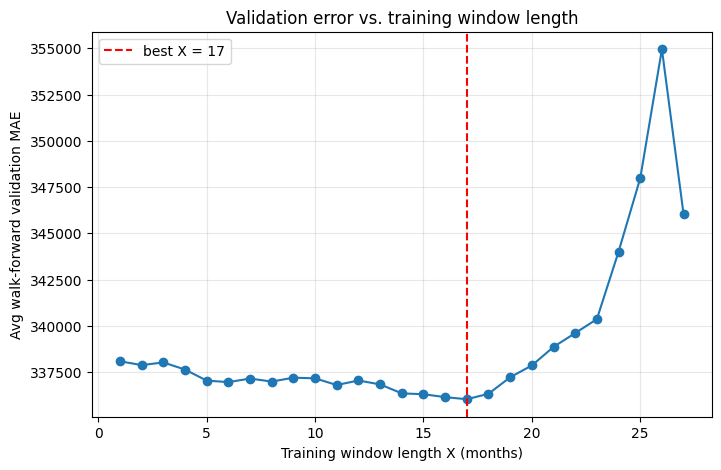

In [17]:
# Visualize error vs. window length as a sanity check before trusting the best_X argmin
import matplotlib.pyplot as plt

xs = list(results.keys())
ys = list(results.values())

plt.figure(figsize=(8, 5))
plt.plot(xs, ys, marker="o")
plt.axvline(best_X, color="red", linestyle="--", label=f"best X = {best_X}")
plt.xlabel("Training window length X (months)")
plt.ylabel("Avg walk-forward validation MAE")
plt.title("Validation error vs. training window length")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
# Build the actual train/test sets using the best training-window length found above
train_window = history_months[-best_X:] if best_X <= len(history_months) else history_months

train_df = prep_df[prep_df["CloseMonth"].isin(train_window)].copy()
test_df = prep_df[prep_df["CloseMonth"] == test_month].copy()

print("Training window (months):", train_window)
print("Test month:", test_month)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Training window (months): ['2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
Test month: 2026-05
Train shape: (173243, 16)
Test shape: (12434, 16)


In [19]:
# Encode City and CountyOrParish on the final train/test split, fitting only on train
def encode_full(train_df, test_df, cat_low_card, cat_high_card):
    train_df = train_df.copy()
    test_df = test_df.copy()

    for col in cat_high_card:
        freq = train_df[col].value_counts(normalize=True)
        train_df[col + "_freq"] = train_df[col].map(freq).fillna(0)
        test_df[col + "_freq"] = test_df[col].map(freq).fillna(0)

    train_dum = pd.get_dummies(train_df[cat_low_card], drop_first=True)
    test_dum = pd.get_dummies(test_df[cat_low_card], drop_first=True)
    test_dum = test_dum.reindex(columns=train_dum.columns, fill_value=False)

    train_df = pd.concat([train_df.drop(columns=cat_low_card).reset_index(drop=True),
                           train_dum.reset_index(drop=True)], axis=1)
    test_df = pd.concat([test_df.drop(columns=cat_low_card).reset_index(drop=True),
                          test_dum.reset_index(drop=True)], axis=1)
    return train_df, test_df


train_enc, test_enc = encode_full(train_df, test_df, cat_low_card, cat_high_card)
train_enc = train_enc.drop(columns=cat_high_card)
test_enc = test_enc.drop(columns=cat_high_card)

print(train_enc.shape, test_enc.shape)
train_enc.head()

(173243, 75) (12434, 75)


,CloseDate,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,DaysOnMarket,CloseMonth,LivingArea_was_missing,...,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba
0,2024-12-09,1120000.0,1151.0,8.0,6.0,6418.0,1979.0,79,2024-12,0,...,False,False,False,False,False,False,False,False,False,False
1,2024-12-19,890000.0,1434.0,3.0,1.0,6473.0,1940.0,0,2024-12,0,...,False,False,False,False,False,False,False,False,False,False
2,2024-12-31,1138000.0,2872.0,5.0,3.0,5219.0,2001.0,0,2024-12,0,...,False,False,False,False,False,False,False,False,False,False
3,2024-12-31,670000.0,800.0,2.0,1.0,23749.0,1952.0,0,2024-12,0,...,False,False,False,False,False,False,False,False,False,False
4,2024-12-23,681877.0,2824.0,5.0,3.0,7000.0,2024.0,0,2024-12,0,...,False,False,False,False,False,False,False,False,False,False


In [20]:
# Split features from target and scale numeric columns, fitting the scaler on train only
drop_cols = ["ClosePrice", "CloseDate", "CloseMonth"]

X_train = train_enc.drop(columns=drop_cols)
y_train = train_enc["ClosePrice"]
X_test = test_enc.drop(columns=drop_cols)
y_test = test_enc["ClosePrice"]

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
X_train.head()

(173243, 72) (173243,)
(12434, 72) (12434,)


,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,DaysOnMarket,LivingArea_was_missing,BathroomsTotalInteger_was_missing,LotSizeSquareFeet_was_missing,YearBuilt_was_missing,...,CountyOrParish_Sonoma,CountyOrParish_Stanislaus,CountyOrParish_Sutter,CountyOrParish_Tehama,CountyOrParish_Trinity,CountyOrParish_Tulare,CountyOrParish_Tuolumne,CountyOrParish_Ventura,CountyOrParish_Yolo,CountyOrParish_Yuba
0,-0.954370,4.677409,2.835194,-0.486048,0.118594,0.773174,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,-0.644458,-0.506330,-1.368948,-0.476767,-1.295108,-0.761471,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,0.930287,1.567165,0.312709,-0.688373,0.916067,-0.761471,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,-1.338748,-1.543078,-1.368948,2.438468,-0.860122,-0.761471,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,0.877723,1.567165,0.312709,-0.387839,1.749788,-0.761471,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [21]:
# Write the cleaned dataset and final train/test sets out to CSV
import os

os.makedirs("output", exist_ok=True)

prep_df.to_csv("output/cleaned_data.csv", index=False)
X_train.assign(ClosePrice=y_train.values).to_csv("output/train.csv", index=False)
X_test.assign(ClosePrice=y_test.values).to_csv("output/test.csv", index=False)

print("Saved:")
print(" output/cleaned_data.csv  ", prep_df.shape)
print(" output/train.csv         ", X_train.shape)
print(" output/test.csv          ", X_test.shape)
print(f"\nChosen training window: X = {best_X} months -> {train_window}")
print(f"Test month: {test_month}")

Saved:
 output/cleaned_data.csv   (313896, 16)
 output/train.csv          (173243, 72)
 output/test.csv           (12434, 72)

Chosen training window: X = 17 months -> ['2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
Test month: 2026-05
